# Notebook 03 — Modèles ML Classiques (Baseline)

## Objectif
Ce notebook implémente deux modèles de Machine Learning classique 
qui serviront de baseline pour comparer avec nos modèles deep learning.

Ces modèles répondent à l'exigence du prof : 
"l'utilisation de méthodes de ML classique est conseillée, 
au moins à titre de comparaison"

## Modèles implémentés
1. K-Nearest Neighbors (KNN) 

## Pipeline commun aux deux modèles
1. Transformer chaque image en histogramme de couleurs (vecteur de 24 valeurs)
2. Entraîner le KNN sur le train
3. Choisir le meilleur K sur la validation
4. Évaluation finale sur le test

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# Chemins
IMAGES_PATH = "../data/images_preprocessees"
TRAIN_CSV = "../data/splits/train.csv"
VAL_CSV = "../data/splits/val.csv"
TEST_CSV = "../data/splits/test.csv"

# Charger les splits
train = pd.read_csv(TRAIN_CSV)
val = pd.read_csv(VAL_CSV)
test = pd.read_csv(TEST_CSV)

print(f"Train : {len(train)} images")
print(f"Validation : {len(val)} images")
print(f"Test : {len(test)} images")

Train : 975 images
Validation : 209 images
Test : 210 images


In [12]:
def image_en_vecteur(chemin_image, bins=8):
    img = cv2.imread(chemin_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    vecteur = []
    
    # Pour chaque canal Rouge, Vert, Bleu
    for canal in range(3):
        # Compter les pixels dans chaque groupe
        hist, _ = np.histogram(img[:,:,canal], bins=bins, range=(0,256))
        # Normaliser pour avoir des pourcentages
        hist = hist / hist.sum()
        vecteur.extend(hist)
    
    return np.array(vecteur)

# Tester
image_test = os.path.join(IMAGES_PATH, train["image"].iloc[0])
vecteur = image_en_vecteur(image_test)
print(f"Vecteur de {len(vecteur)} valeurs : {vecteur.round(3)}")

Vecteur de 24 valeurs : [0.065 0.012 0.025 0.052 0.083 0.23  0.432 0.101 0.067 0.039 0.074 0.144
 0.363 0.261 0.05  0.002 0.076 0.081 0.171 0.331 0.268 0.067 0.007 0.   ]


In [13]:
# Transformer toutes les images en vecteurs
def charger_dataset(df):
    X = []  # vecteurs
    y = []  # labels
    
    for idx, row in df.iterrows():
        chemin = os.path.join(IMAGES_PATH, row["image"])
        
        # Vérifier que l'image existe
        if os.path.exists(chemin):
            vecteur = image_en_vecteur(chemin)
            X.append(vecteur)
            y.append(row["niveau"])
    
    return np.array(X), np.array(y)

print("Chargement du train...")
X_train, y_train = charger_dataset(train)

print("Chargement de la validation...")
X_val, y_val = charger_dataset(val)

print("Chargement du test...")
X_test, y_test = charger_dataset(test)

print(f"\nTrain  : {X_train.shape}")
print(f"Val    : {X_val.shape}")
print(f"Test   : {X_test.shape}")

Chargement du train...


Chargement de la validation...
Chargement du test...

Train  : (975, 24)
Val    : (209, 24)
Test   : (210, 24)


In [14]:
# MODELE 1 — KNN
print("=== KNN ===")

# Tester plusieurs valeurs de K
resultats_k = []
for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_val = knn.predict(X_val)
    acc = accuracy_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val, average="macro")
    resultats_k.append({"K": k, "Accuracy": acc, "F1-Score": f1})
    print(f"K={k} → Accuracy: {acc:.3f} | F1-Score: {f1:.3f}")

# Garder le meilleur K
df_resultats = pd.DataFrame(resultats_k)
meilleur_k = df_resultats.loc[df_resultats["Accuracy"].idxmax(), "K"]
print(f"\nMeilleur K : {meilleur_k}")

=== KNN ===
K=3 → Accuracy: 0.450 | F1-Score: 0.356
K=5 → Accuracy: 0.440 | F1-Score: 0.286
K=7 → Accuracy: 0.445 | F1-Score: 0.331
K=9 → Accuracy: 0.440 | F1-Score: 0.349
K=11 → Accuracy: 0.469 | F1-Score: 0.359

Meilleur K : 11


=== KNN (K=11) — Résultats finaux ===
Accuracy : 0.448
F1-Score : 0.308


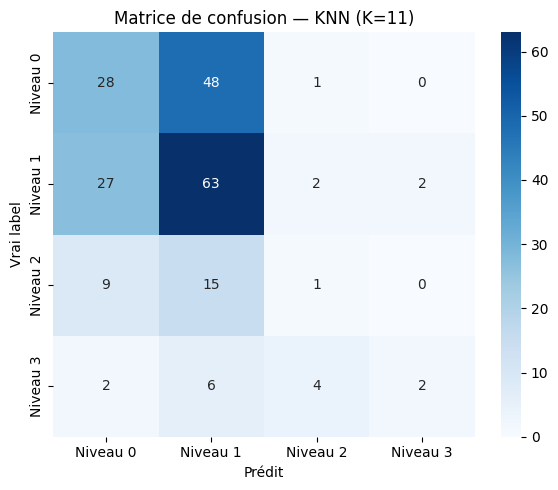

In [17]:
# Evaluation finale du KNN sur le test set
knn_final = KNeighborsClassifier(n_neighbors=int(meilleur_k))
knn_final.fit(X_train, y_train)
y_pred_test = knn_final.predict(X_test)

acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, average="macro")

print(f"=== KNN (K={int(meilleur_k)}) — Résultats finaux ===")
print(f"Accuracy : {acc_test:.3f}")
print(f"F1-Score : {f1_test:.3f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Niveau 0", "Niveau 1", "Niveau 2", "Niveau 3"],
            yticklabels=["Niveau 0", "Niveau 1", "Niveau 2", "Niveau 3"])
plt.title(f"Matrice de confusion — KNN (K={int(meilleur_k)})")
plt.ylabel("Vrai label")
plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig("../results/figures/matrice_knn.png", dpi=150, bbox_inches='tight')
plt.show()



Le KNN (K=11) atteint 44.8% d'accuracy et ne détecte presque jamais 
les niveaux 2 et 3. L'histogramme de couleurs est insuffisant pour 
capturer les patterns complexes de l'acné. Cela justifie l'utilisation 
du deep learning.

In [16]:
plt.savefig("../results/figures/matrice_knn.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>